In [4]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)


import importlib
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import A2C
import matplotlib.pyplot as plt
import torch

# Import as module
import environment.users.citation_users_loader as citation_users_loader
importlib.reload(citation_users_loader)

import environment.citations.citation_selector as citation_selector
importlib.reload(citation_selector)

import environment.citation_reward_shaping as citation_reward_shaping
importlib.reload(citation_reward_shaping)

import environment.citations.citation as citation
importlib.reload(citation)

import environment.users.citation_user as citation_user
importlib.reload(citation_user)

import environment.citations.citation_loader as citation_loader
importlib.reload(citation_loader)

import environment.citation_memory as citation_memory
importlib.reload(citation_memory)

import environment.users.user_rater as user_rater
importlib.reload(user_rater)

import environment.user_env as user_env
importlib.reload(user_env)

from environment.user_env import UserEnv
from environment.users.citation_users_loader import CitationUsersLoader
from environment.citations.citation_loader import CitationsLoader
from environment.citations.citation import Citation
from environment.citations.citation_selector import CitationsSelector
from environment.citation_memory import CitationMemory
from environment.users.citation_user import CitationUser
from environment.users.user_rater import RuleBasedCitationRater
from environment.citation_reward_shaping import CitationRewardReshapingExpDecay

In [5]:
users_loader = CitationUsersLoader("../environment/users/datasets/users_with_popular_interests.json")
user_list = users_loader.get_users()
paper_loader = CitationsLoader("../environment/citations/datasets/cleaned-scientometrics-and-bibliometrics-research.csv")
selector = CitationsSelector()
rater = RuleBasedCitationRater()
reward_shaping = CitationRewardReshapingExpDecay()

In [6]:
user_rewards = []
timesteps = 50000

for user in user_list:
    env = UserEnv(
        render_mode= "human",
        items_loader=paper_loader,
        user_list=[user],
        items_selector=selector,
        reward_shaping=reward_shaping,
        render_path="./tmp/render/",
        debug=True,
        debug_path=f"debug_log/user_env_A2C_user{user.id}_{timesteps}.log",
    )
    env = Monitor(env)

    model = A2C(
        policy="MultiInputPolicy",
        env=env,
        learning_rate=1e-4,       # You can tune this
        gamma=0.99,               # Discount factor
        n_steps=5,                # Rollout length before updating the model (like batch size)
        ent_coef=0.01,            # Entropy coefficient to encourage exploration
        vf_coef=0.5,              # Value function loss weight
        max_grad_norm=0.5,        # Gradient clipping
        use_rms_prop=True,        # Use RMSprop optimizer (as in original A2C paper)
        normalize_advantage=True, # Helps stability
        verbose=1,
        device="cpu"              # or "cuda"
    )
            
    model.learn(total_timesteps=timesteps)
    user_rewards.append(env.get_episode_rewards())


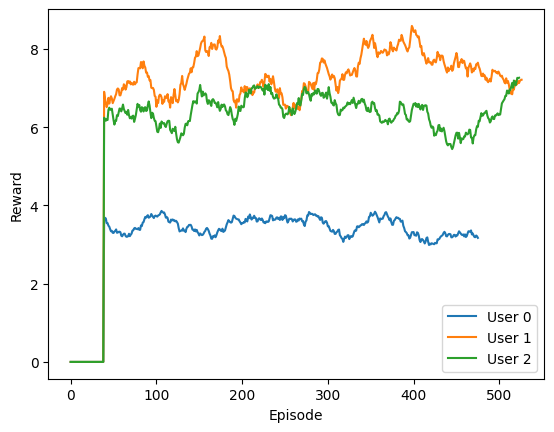

In [8]:
def plot_rewards(all_user_rewards, window_size=40):
    """
    all_user_rewards: list of lists/arrays, each one is the rewards for one user
    window_size: smoothing window for moving average
    """
    plt.xlabel('Episode')
    plt.ylabel('Reward')

    for i, rewards in enumerate(all_user_rewards):
        rewards_t = torch.tensor(rewards, dtype=torch.float)

        # raw rewards (optional)
        # plt.plot(rewards_t.numpy(), alpha=0.2, label=f'run {i} raw')

        # smoothed (moving average)
        if len(rewards_t) >= window_size:
            means = rewards_t.unfold(0, window_size, 1).mean(1).view(-1)
            # pad the beginning so lengths match
            pad = torch.zeros(window_size - 1)
            smoothed = torch.cat((pad, means))
            plt.plot(smoothed.numpy(), label=f'User {i}')
        else:
            # too short to smooth, just plot raw
            plt.plot(rewards_t.numpy(), label=f'User {i}')

    plt.legend()
    plt.show()

plot_rewards(user_rewards)